In [1]:
import matplotlib
import matplotlib.pyplot as plt

import scanpy as sc

In [ ]:
import os
os.chdir("/public/home/off_liukunpeng/project/11_cluster_problem")
import sys
sys.path.append("/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/")

In [3]:
import glob
import pandas as pd
from matplotlib.lines import Line2D

In [4]:
!ls comparison/*/Dataset11_Human_Lymph_Node_A1.h5ad

comparison/MOFA/Dataset11_Human_Lymph_Node_A1.h5ad
comparison/cosmos/Dataset11_Human_Lymph_Node_A1.h5ad
comparison/multivi/Dataset11_Human_Lymph_Node_A1.h5ad
comparison/spatial_glue/Dataset11_Human_Lymph_Node_A1.h5ad
comparison/totalVI/Dataset11_Human_Lymph_Node_A1.h5ad


In [5]:
!ls comparison/*/Dataset11_Human_Lymph_Node_A1_RNA*

comparison/STAGATE/Dataset11_Human_Lymph_Node_A1_RNA.h5ad
comparison/STMGraph/Dataset11_Human_Lymph_Node_A1_RNA.h5ad
comparison/deepst/Dataset11_Human_Lymph_Node_A1_RNA.h5ad
comparison/spaGCN/Dataset11_Human_Lymph_Node_A1_RNA.h5ad


In [6]:
data_set=[
"Dataset1_Mouse_Spleen1.h5ad",
"Dataset2_Mouse_Spleen2.h5ad",
"Dataset3_Mouse_Thymus1.h5ad",
"Dataset4_Mouse_Thymus2.h5ad",
"Dataset5_Mouse_Thymus3.h5ad",
"Dataset6_Mouse_Thymus4.h5ad" 
"Dataset7_Mouse_Brain_ATAC.h5ad",
"Dataset8_Mouse_Brain_H3K4me3.h5ad",
"Dataset9_Mouse_Brain_H3K27ac.h5ad",
"Dataset10_Mouse_Brain_H3K27me3.h5ad",
"Dataset11_Human_Lymph_Node_A1.h5ad",
"Dataset12_Human_Lymph_Node_D1.h5ad",
"Dataset13_Simulation1.h5ad",
"Dataset14_Simulation2.h5ad",
"Dataset15_Simulation3.h5ad",
"Dataset16_Simulation4.h5ad",
"Dataset17_Simulation5.h5ad",
]
data_set2=[
"Dataset1_Mouse_Spleen1_RNA.h5ad",
"Dataset2_Mouse_Spleen2_RNA.h5ad",
"Dataset3_Mouse_Thymus1_RNA.h5ad",
"Dataset4_Mouse_Thymus2_RNA.h5ad",
"Dataset5_Mouse_Thymus3_RNA.h5ad",
"Dataset6_Mouse_Thymus4_RNA.h5ad" 
"Dataset7_Mouse_Brain_ATAC_RNA.h5ad",
"Dataset8_Mouse_Brain_H3K4me3_RNA.h5ad",
"Dataset9_Mouse_Brain_H3K27ac_RNA.h5ad",
"Dataset10_Mouse_Brain_H3K27me3_RNA.h5ad",
"Dataset11_Human_Lymph_Node_A1_RNA.h5ad",
"Dataset12_Human_Lymph_Node_D1_RNA.h5ad",
"Dataset13_Simulation1_RNA.h5ad",
"Dataset14_Simulation2_RNA.h5ad",
"Dataset15_Simulation3_RNA.h5ad",
"Dataset16_Simulation4_RNA.h5ad",
"Dataset17_Simulation5_RNA.h5ad",
]


software_path=[
"comparison/MOFA/",
"comparison/multivi/",
"comparison/totalVI/",
"comparison/spatial_glue/",

"comparison/STAGATE/",
"comparison/STMGraph/",
"comparison/spaGCN/",
"comparison/deepst/",

]

In [7]:
!ls comparison/

MEFISTO  STAGATE   cosmos  multivi  spaGCN	  totalVI
MOFA	 STMGraph  deepst  scMM     spatial_glue


In [8]:
mofa_h5ad_path=glob.glob("comparison/MOFA/*h5ad")
multivi_h5ad_path=glob.glob("comparison/multivi/*h5ad")
spatialglue_h5ad_path=glob.glob("comparison/spatial_glue/*h5ad")
totalvi_h5ad_path=glob.glob("comparison/totalVI/*h5ad")

In [9]:
def leiden_cluster(adata,key,resolution):
    sc.pp.neighbors(adata, use_rep=key)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, key_added=key,resolution=resolution)
    sc.pl.embedding(adata, basis='spatial', color=key, title=key, s=100, show=False)
    return adata

In [10]:
sc.read_h5ad(software_path[0]+data_set[6])

AnnData object with n_obs × n_vars = 9548 × 22731
    obs: 'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'nCount_H3K4me3', 'nFeature_H3K4me3', 'nCount_peaks', 'nFeature_peaks', 'RNA_clusters', 'H3K4me3_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'name', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    obsm: 'X_lsi', 'X_mofa', 'X_pca', 'X_umap', 'spatial'
    layers: 'counts', 'lognorm'

In [11]:
# comparison/cosmos/Dataset11_Human_Lymph_Node_A1.h5ad
# comparison/MOFA/Dataset11_Human_Lymph_Node_A1.h5ad
# comparison/multivi/Dataset11_Human_Lymph_Node_A1.h5ad
# comparison/totalVI/Dataset11_Human_Lymph_Node_A1.h5ad
# comparison/spatial_glue/Dataset11_Human_Lymph_Node_A1.h5ad

In [12]:
software_0=sc.read_h5ad("comparison/MOFA/Dataset11_Human_Lymph_Node_A1.h5ad")
software_1=sc.read_h5ad("comparison/multivi/Dataset11_Human_Lymph_Node_A1.h5ad")
software_2=sc.read_h5ad("comparison/totalVI/Dataset11_Human_Lymph_Node_A1.h5ad")
software_3=sc.read_h5ad("comparison/spatial_glue/Dataset11_Human_Lymph_Node_A1.h5ad")
software_4=sc.read_h5ad("comparison/cosmos/Dataset11_Human_Lymph_Node_A1.h5ad")

STAGATE_  =sc.read_h5ad(software_path[4]+data_set2[9])
STMGraph  =sc.read_h5ad(software_path[5]+data_set2[9])
spaGCN__  =sc.read_h5ad(software_path[6]+data_set2[9])
deepst__  =sc.read_h5ad(software_path[7]+data_set2[9])

deepst__  =sc.read_h5ad(software_path[7]+data_set2[9])


AgaeSMO_adata=sc.read_h5ad("AgaeSMO/result/Dataset11_Human_Lymph_Node_A1.h5ad")
annotation=pd.read_csv('data/sg/Dataset11_Human_Lymph_Node_A1/annotation.csv')
# annotation1=pd.DataFrame(annotation.loc[:,'manual-anno'])
AgaeSMO_adata.obs['Ground Truth']=annotation.loc[:,'manual-anno'].to_list()

/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


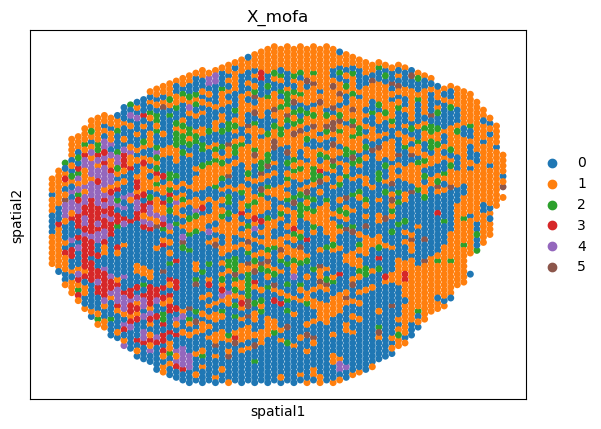

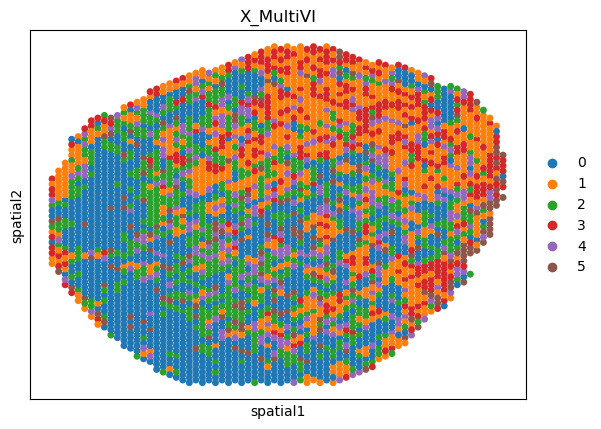

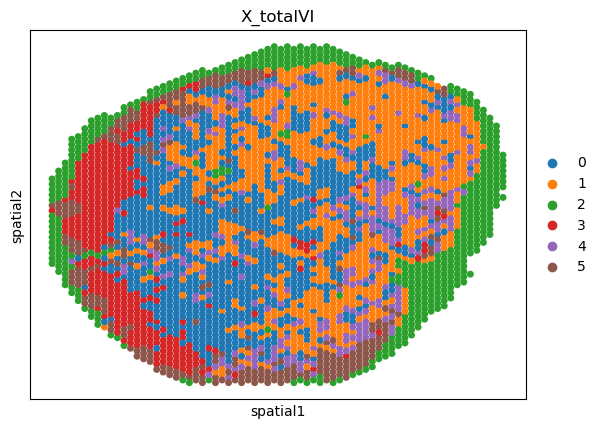

In [13]:
software_0=leiden_cluster(software_0,"X_mofa",0.18)
software_1=leiden_cluster(software_1,"X_MultiVI",0.013)
software_2=leiden_cluster(software_2,"X_totalVI",0.75)

/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'Ground Truth'}, xlabel='spatial1', ylabel='spatial2'>

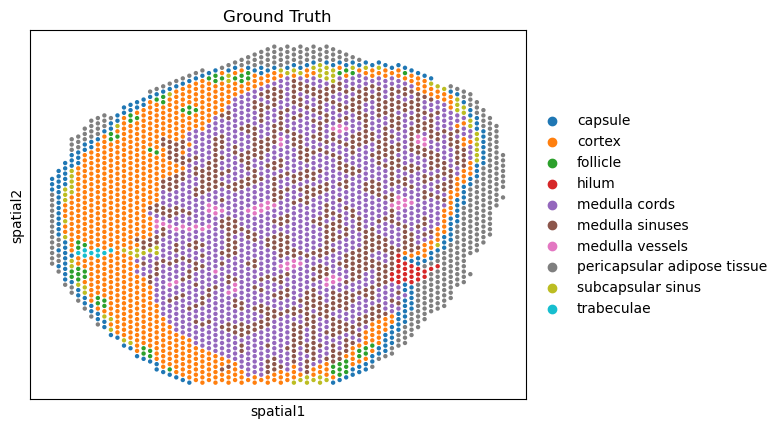

In [14]:
sc.pl.embedding(AgaeSMO_adata, basis='spatial', color="Ground Truth", title="Ground Truth" ,s=40, show=False)

In [15]:
AgaeSMO_adata.uns['Ground Truth_colors']

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

In [16]:
AgaeSMO_adata.uns['Ground Truth_colors']=\
['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']
color_dir={
    1:'#9467bd',
    2:'#ff7f0e',
    3:'#7f7f7f',
    4:'#1f77b4',
    5:'#2ca02c',
    6:'#8c564b'
}
[color_dir[1],color_dir[2],color_dir[3],color_dir[4],color_dir[5],color_dir[6]]

['#9467bd', '#ff7f0e', '#7f7f7f', '#1f77b4', '#2ca02c', '#8c564b']

/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


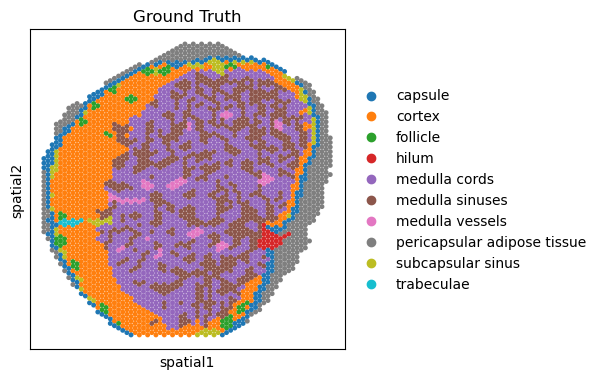

In [17]:
fig,ax=plt.subplots(1,figsize=(7,4))
sc.pl.embedding(AgaeSMO_adata, basis='spatial', color="Ground Truth", title=f"Ground Truth" ,ax=ax,s=50, show=False)
plt.subplots_adjust(left=0.05, bottom=0.1, right=0.5, top=0.9, wspace=0.05, hspace=0.2)
# ax.legend(fontsize=15)
# fig.savefig("plot/fig2_d.png",dpi=600)

In [18]:
print(STAGATE_)
print(STMGraph)
print(spaGCN__)
print(deepst__)

AnnData object with n_obs × n_vars = 3484 × 18085
    obs: 'mclust'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'Spatial_Net', 'hvg', 'log1p', 'neighbors', 'umap'
    obsm: 'STAGATE', 'X_umap', 'spatial'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 3484 × 18036
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'log1p_total_counts_ercc', 'pct_counts_ercc', 'mclust', 'refine_mclust'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ercc', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'me

In [19]:
# print()

In [20]:
obsm=[
"AgaeSMO",    
  
"X_mofa",     
"X_MultiVI",  
"X_totalVI",  
"SpatialGlue",

"Cluster_cosmos",
    
"mclust",              
"refine_mclust",       
"refined_pred",        
"DeepST_refine_domain",
]
ARIs=[]
from sklearn import metrics
for n,i in enumerate([
AgaeSMO_adata,

software_0,
software_1,
software_2,
software_3,

software_4,

STAGATE_  ,
STMGraph  ,
spaGCN__  ,
deepst__  ,

]):
    ARI = metrics.adjusted_rand_score(AgaeSMO_adata.obs['Ground Truth'],i.obs[obsm[n]])
    ARIs.append(round(ARI,4))
print(ARIs)

[0.3779, 0.044, 0.018, 0.2932, 0.3081, 0.2484, 0.2241, 0.2267, 0.25, 0.2431]


/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software

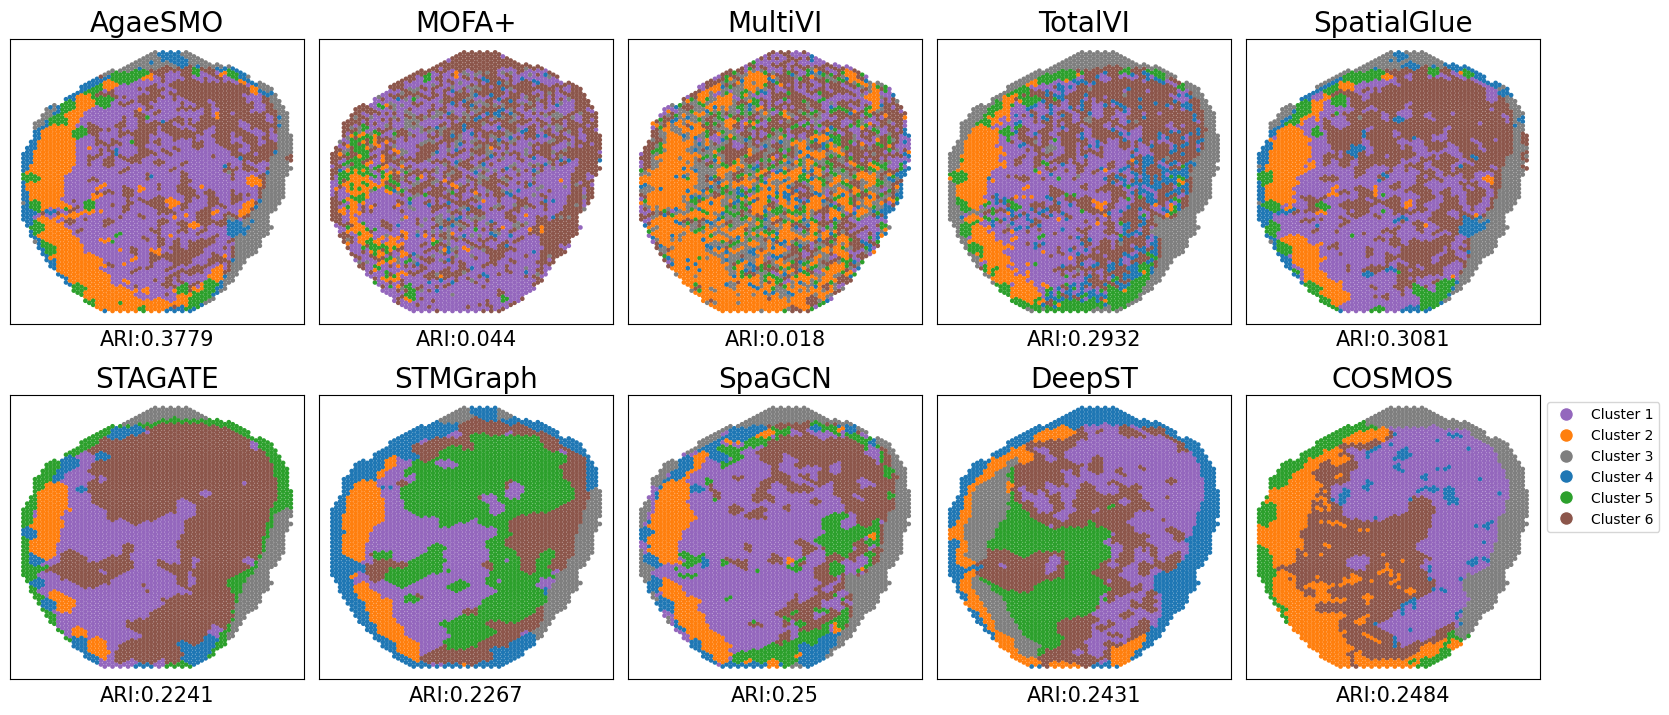

In [21]:
# grid = plt.GridSpec(2, 3, wspace=0.4, hspace=0.3)
AgaeSMO_adata.uns['AgaeSMO_colors']      = [color_dir[1],color_dir[6],color_dir[4],color_dir[3],color_dir[2],color_dir[5]]
software_0.uns['X_mofa_colors']      = [color_dir[1],color_dir[6],color_dir[3],color_dir[2],color_dir[5],color_dir[4]]
software_1.uns['X_MultiVI_colors']   = [color_dir[2],color_dir[6],color_dir[3],color_dir[1],color_dir[5],color_dir[4]]
software_2.uns['X_totalVI_colors']   = [color_dir[1],color_dir[6],color_dir[3],color_dir[2],color_dir[4],color_dir[5]]
software_3.uns['SpatialGlue_colors'] = [color_dir[1],color_dir[6],color_dir[2],color_dir[3],color_dir[5],color_dir[4]]
software_4.uns['Cluster_cosmos_colors'] = [color_dir[1],color_dir[6],color_dir[2],color_dir[3],color_dir[5],color_dir[4]]

STAGATE_.uns['mclust_colors']               = [color_dir[1],color_dir[5],color_dir[6],color_dir[2],color_dir[3],color_dir[4]]
STMGraph.uns['refine_mclust_colors']        = [color_dir[3],color_dir[6],color_dir[1],color_dir[5],color_dir[4],color_dir[2]]
spaGCN__.uns['refined_pred_colors']         = [color_dir[1],color_dir[1],color_dir[6],color_dir[3],color_dir[2],color_dir[5],color_dir[4]]
deepst__.uns['DeepST_refine_domain_colors'] = [color_dir[1],color_dir[6],color_dir[5],color_dir[4],color_dir[3],color_dir[2]]

fig,ax=plt.subplots(2,5,figsize=(18,8))
plt.subplots_adjust(left=0.05, bottom=0.1, right=0.9, top=0.9, wspace=0.05, hspace=0.25)

# sc.pl.embedding(AgaeSMO_adata, basis='spatial', color="Ground Truth", title=f"Ground Truth",ax=ax[0,0] ,s=45, show=False)
sc.pl.embedding(AgaeSMO_adata, basis='spatial', color="AgaeSMO",        title=f"AgaeSMO",           ax=ax[0,0] ,s=45, show=False)
sc.pl.embedding(software_0,  basis='spatial', color="X_mofa",       title=f"MOFA+",           ax=ax[0,1] ,s=45, show=False)
sc.pl.embedding(software_1,  basis='spatial', color="X_MultiVI",    title=f"MultiVI",         ax=ax[0,2] ,s=45, show=False)
sc.pl.embedding(software_2,  basis='spatial', color="X_totalVI",    title=f"TotalVI",         ax=ax[0,3] ,s=45, show=False)
sc.pl.embedding(software_3,  basis='spatial', color="SpatialGlue",  title=f"SpatialGlue",     ax=ax[0,4] ,s=45, show=False)

sc.pl.embedding(software_4,  basis='spatial', color="Cluster_cosmos",  title=f"COSMOS",     ax=ax[1,4] ,s=45, show=False)

sc.pl.embedding(STAGATE_,  basis='spatial', color="mclust",                title=f"STAGATE",  ax=ax[1,0] ,s=45, show=False)
sc.pl.embedding(STMGraph,  basis='spatial', color="refine_mclust",         title=f"STMGraph", ax=ax[1,1] ,s=45, show=False)
sc.pl.embedding(spaGCN__,  basis='spatial', color="refined_pred",          title=f"SpaGCN",   ax=ax[1,2] ,s=45, show=False)
sc.pl.embedding(deepst__,  basis='spatial', color="DeepST_refine_domain",  title=f"DeepST",   ax=ax[1,3] ,s=45, show=False)
for i in ax:
    for j in i:
        j.set_xlabel(None)
        j.set_ylabel(None)
        j.set_title(j.title.get_text(), fontsize=20)
        legend = j.legend()
        legend.set_visible(False)  # 隐藏图例

ax[0,0].set_xlabel(f"ARI:{ARIs[0]}", fontsize=15)

ax[0,1].set_xlabel(f"ARI:{ARIs[1]}", fontsize=15)
ax[0,2].set_xlabel(f"ARI:{ARIs[2]}", fontsize=15)
ax[0,3].set_xlabel(f"ARI:{ARIs[3]}", fontsize=15)
ax[0,4].set_xlabel(f"ARI:{ARIs[4]}", fontsize=15)

ax[1,4].set_xlabel(f"ARI:{ARIs[5]}", fontsize=15)

ax[1,0].set_xlabel(f"ARI:{ARIs[6]}", fontsize=15)
ax[1,1].set_xlabel(f"ARI:{ARIs[7]}", fontsize=15)
ax[1,2].set_xlabel(f"ARI:{ARIs[8]}", fontsize=15)
ax[1,3].set_xlabel(f"ARI:{ARIs[9]}", fontsize=15)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Cluster 1',       markerfacecolor="#9467bd", markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cluster 2',       markerfacecolor="#ff7f0e", markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cluster 3',       markerfacecolor="#7f7f7f", markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cluster 4',       markerfacecolor="#1f77b4", markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cluster 5',       markerfacecolor="#2ca02c", markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cluster 6',       markerfacecolor="#8c564b", markersize=10),
]
# ax[1,4].legend(handles=legend_elements, ncol=1,loc= 'upper left' ,fontsize=20)
# ax[1,4].set_xlabel(None)
# ax[1,4].set_ylabel(None)
# ax[1,4].spines['top'].set_visible(False)
# ax[1,4].spines['right'].set_visible(False)
# ax[1,4].spines['left'].set_visible(False)
# ax[1,4].spines['bottom'].set_visible(False)

# 隐藏坐标轴的刻度（包括刻度线和刻度标签）
# ax[1,4].tick_params(axis='both', which='both', length=0, labelsize=0)
ax[1,4].legend(handles=legend_elements,ncol=1,fontsize=10,bbox_to_anchor=(1, 1))

# fig.savefig("plot/fig2_a.png",dpi=600)

In [22]:
AgaeSMO_adata

AnnData object with n_obs × n_vars = 3484 × 17954
    obs: 'mclust', 'AgaeSMO', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'AgaeSMO_colors', 'adj_spatial', 'adj_spatial_', 'hvg', 'log1p', 'neighbors', 'umap', 'Ground Truth_colors'
    obsm: 'AgaeSMO', 'AgaeSMO_pca', 'X_umap', 'adj_feature', 'alpha', 'emb_latent_omics1', 'emb_latent_omics2', 'feat', 'spatial', 'tensor'
    obsp: 'connectivities', 'distances'

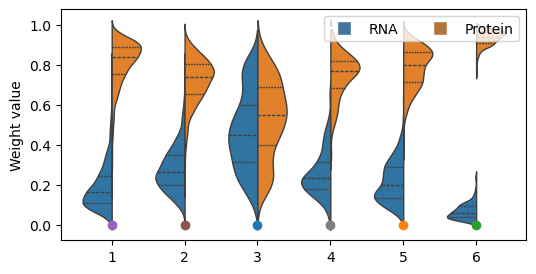

In [23]:
import seaborn as sns
def plot_weight_value(alpha, label, modality1='mRNA', modality2='protein',show=True):
  """\
  Plotting weight values
  
  """  
  import pandas as pd  
  
  df = pd.DataFrame(columns=[modality1, modality2, 'label'])  
  df[modality1], df[modality2] = alpha[:, 0], alpha[:, 1]
  df['label'] = label
  df = df.set_index('label').stack().reset_index()
  df.columns = ['label', 'Modality', 'Weight value']
  return df
  ax = sns.violinplot(data=df, y='Weight value', hue="Modality",
                split=True, inner="quart", linewidth=1)
  ax.set_title(modality1 + ' vs ' + modality2) 

  plt.tight_layout(w_pad=0.05)
  if show:
    plt.show() 
from matplotlib.lines import Line2D
fig,ax=plt.subplots(1,figsize=(6,3))




for n,i in enumerate(set(AgaeSMO_adata.obs["AgaeSMO"])):
    alpha=AgaeSMO_adata.obsm["alpha"][AgaeSMO_adata.obs["AgaeSMO"]==i,:]
    
    df=plot_weight_value(alpha,"AgaeSMO",modality1='mRNA', modality2='MSI')
    sns.violinplot(data=df,ax=ax,x=n+1,y='Weight value', hue="Modality",
                split=True, inner="quart", linewidth=1)
    
    ax.scatter(n,0,c=AgaeSMO_adata.uns["AgaeSMO_colors"][n])
ax.legend().set_visible(False)
#     ax[j].set_title(titles[j])
#     legend = ax[j].legend()
#     legend.set_visible(False)
#     # break
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='RNA',       markerfacecolor="#44739d", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Protein',       markerfacecolor="#b2753d", markersize=10),
]
ax.legend(handles=legend_elements, ncol=2,loc= 'upper right' ,fontsize=10)
# fig.savefig("plot/fig2_a_alpha.png",dpi=600)